In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from skmatter.preprocessing import StandardFlexibleScaler

In [2]:
df = pd.read_csv('./Photonics_1/gen_photonics_data.csv')

In [20]:
X_raw = np.array(df.iloc[:, 0:2])

y_raw = np.zeros((X_raw.shape[0], 3), dtype=float)
y_raw_bool = np.zeros((X_raw.shape[0], 1), dtype=bool)
for i, yy in enumerate(np.array(df.iloc[:, 2:])):
    y_raw[i][:2] = yy
    y_raw[i][2] = (yy[1]-yy[0])/(0.5 * (yy[0]+yy[1])) if (yy[1]-yy[0])>0 else 0
    y_raw_bool[i] = bool(yy[0]<yy[1])
y_raw

array([[0.52587283, 0.57538368, 0.08991701],
       [0.37296769, 0.29137188, 0.        ],
       [0.30061037, 0.29742975, 0.        ],
       [0.576427  , 0.54518939, 0.        ],
       [1.01537268, 0.84029535, 0.        ],
       [0.32302943, 0.25255271, 0.        ],
       [0.42462781, 0.46783102, 0.09681838],
       [0.48499548, 0.53958407, 0.10655802],
       [0.61044377, 0.57249178, 0.        ],
       [0.72997718, 0.69808946, 0.        ],
       [0.47469927, 0.427217  , 0.        ],
       [0.34153395, 0.32489079, 0.        ],
       [0.63687643, 0.60323176, 0.        ],
       [0.32949049, 0.35527843, 0.07531866],
       [0.31031623, 0.3063514 , 0.        ],
       [0.45706855, 0.44557369, 0.        ],
       [0.65844991, 0.67130195, 0.01932997],
       [0.76165491, 0.70099876, 0.        ],
       [0.52379661, 0.54140441, 0.03306007],
       [0.36017737, 0.30850916, 0.        ],
       [0.27977652, 0.21889232, 0.        ],
       [0.42123525, 0.43980231, 0.04312717],
       [0.

In [21]:
x_scaler = StandardScaler()
X = x_scaler.fit_transform(X_raw)

y_scaler = StandardFlexibleScaler(column_wise=True)
y = y_scaler.fit_transform(y_raw)

In [27]:
X_train, X_test, y_train, y_test, y_train_bool, y_test_bool = train_test_split(X, y, y_raw_bool, test_size=0.2, random_state=42, shuffle=True)

In [28]:
model = RidgeCV(alphas=np.logspace(-8, 2, 100), cv=5, fit_intercept=False)

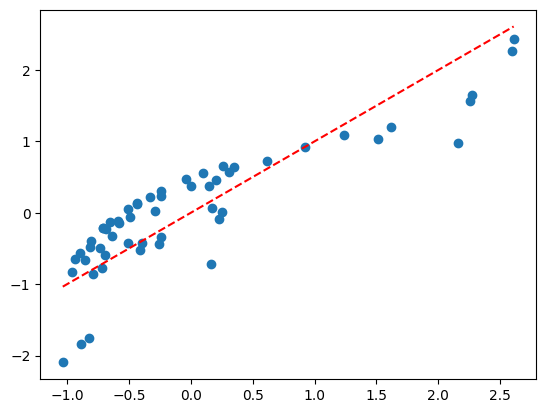

In [29]:
## Band 2
model.fit(X_train, y_train[:,0])
plt.scatter(y_test[:,0], model.predict(X_test))
plt.plot([y_test[:,0].min(), y_test[:,0].max()], [y_test[:,0].min(), y_test[:,0].max()], 'r--')

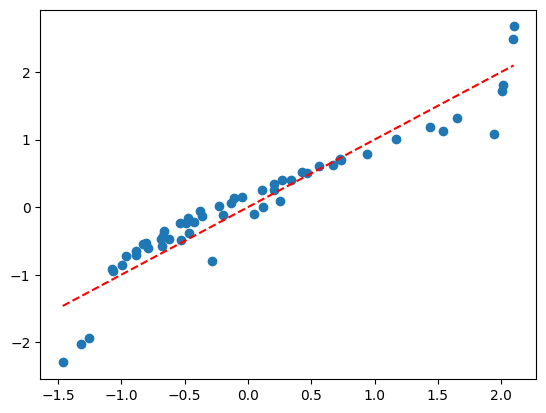

In [30]:
## Band 3
model.fit(X_train, y_train[:,1])
plt.scatter(y_test[:,1], model.predict(X_test))
plt.plot([y_test[:,1].min(), y_test[:,1].max()], [y_test[:,1].min(), y_test[:,1].max()], 'r--')

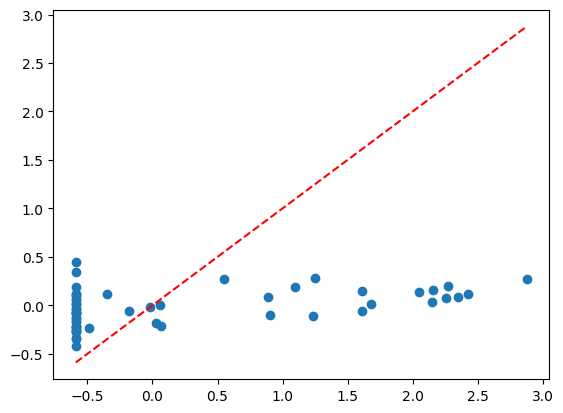

In [31]:
## Gap Size
model.fit(X_train, y_train[:, 2])
plt.scatter(y_test[:, 2], model.predict(X_test))
plt.plot(
    [y_test[:, 2].min(), y_test[:, 2].max()],
    [y_test[:, 2].min(), y_test[:, 2].max()],
    "r--",
)

/opt/miniconda3/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


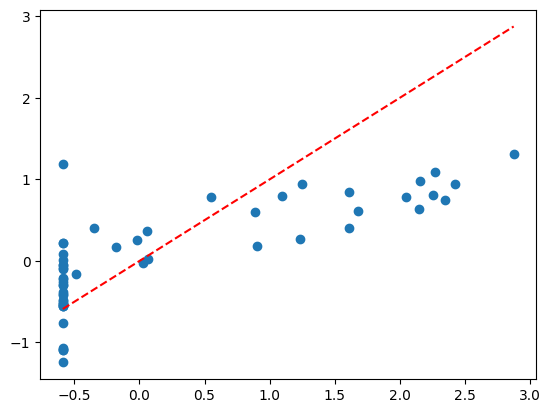

In [37]:
# Just a demonstration of what we can get with deeper architectures
# Spoiler alert: it's not much better
from sklearn.neural_network import MLPRegressor

model = MLPRegressor()

## Gap Size
model.fit(X_train, y_train[:, 2])
plt.scatter(y_test[:, 2], model.predict(X_test))
plt.plot(
    [y_test[:, 2].min(), y_test[:, 2].max()],
    [y_test[:, 2].min(), y_test[:, 2].max()],
    "r--",
)

/opt/miniconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


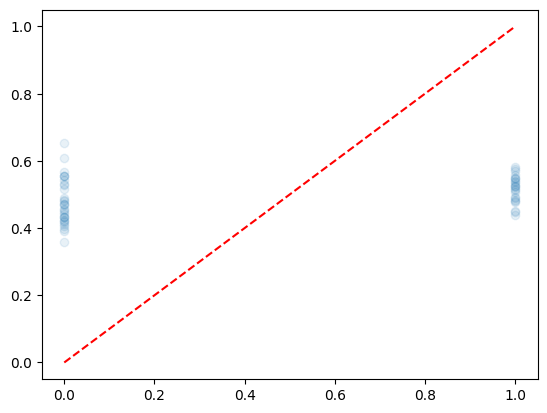

In [36]:
from sklearn.linear_model import LogisticRegressionCV

## Whether there is a Gap
model = LogisticRegressionCV(Cs=np.logspace(-2, 3, 10), cv=5, fit_intercept=False)

model.fit(X_train, y_train_bool)
# model.predict_log_proba
plt.scatter(y_test_bool, model.predict_proba(X_test)[:,1], alpha=0.1)
plt.plot([y_test_bool.min(), y_test_bool.max()], [y_test_bool.min(), y_test_bool.max()], 'r--')